# Relative error vs code parameters (CPP experiments)

This notebook loads relative error CSVs from `/mnthdd/cpanourg/2-hdvc/results/relerr_cpp` and plots:

- Relative error vs **number of subquantizers**
- Relative error vs **bits per subvector (`nbits`)**
- Relative error vs **bits per vector**

Figures are styled similarly to those in `DARTH_plus_conformal.ipynb` (font sizes, figure sizes, and general aesthetics).

In [29]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogLocator

# --- Plot style (aligned with DARTH_plus_conformal.ipynb) ---
# Base style - will be overridden to font.size=40 for individual plots
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("/data/cpanourg/2-hdvc/results/relerr_cpp")
CSV_PATTERN = "*_adc_vs_exact_eval.csv"

In [30]:
from glob import glob

def load_relerr_data(data_dir: Path, pattern: str = CSV_PATTERN) -> pd.DataFrame:
    """Load and concatenate all relative-error CSVs in `data_dir`.

    Assumes filenames of the form `{dataset}_{method}_adc_vs_exact_eval.csv`.
    """
    csv_paths = sorted(data_dir.glob(pattern))
    if not csv_paths:
        raise FileNotFoundError(f"No CSVs matching {pattern!r} found in {data_dir}")

    dfs = []
    for path in csv_paths:
        df = pd.read_csv(path)

        # Infer dataset/method from filename if needed
        name = path.stem  # e.g., deep_OPQ_adc_vs_exact_eval
        parts = name.split("_")
        if len(parts) >= 2:
            file_dataset, file_method = parts[0], parts[1]
            if "dataset" not in df.columns:
                df["dataset"] = file_dataset
            if "method" not in df.columns:
                df["method"] = file_method
        dfs.append(df)

    all_df = pd.concat(dfs, ignore_index=True)

    # Ensure expected columns exist
    required_cols = [
        "method",
        "dataset",
        "n_subquantizers",
        "nbits",
        "bits_per_vector",
        "rel_error_mean",
        "rel_error_std",
    ]
    missing = [c for c in required_cols if c not in all_df.columns]
    if missing:
        raise ValueError(f"Missing columns in concatenated DF: {missing}")

    return all_df

relerr_df = load_relerr_data(DATA_DIR)
relerr_df.head()

# ============================================================================
# CONFIGURATION: Select methods, datasets, and x-axis columns to plot
# ============================================================================

# Select which methods to plot (available: OPQ, PQ)
METHODS_TO_PLOT = ["PQ"]  # Change to ["OPQ"] or ["PQ"] to plot only one

# Select which datasets to plot (available: deep, gist)
DATASETS_TO_PLOT = ["deep"]  # Change to ["deep"] or ["gist"] to plot only one

# Select which x-axis columns to plot (column_name, display_label)
# Available columns: n_subquantizers, nbits, bits_per_vector, or any other numeric column
X_COLUMNS_TO_PLOT = [
    ("n_subquantizers", "Num subq"),
    # ("nbits", "nbits"),
    # ("bits_per_vector", "Bits per vector"),
    # ("adc_time_s", "ADC time (seconds)"),  # Relative error vs asymmetric distance computation time
    # ("distance_table_time_s", "Distance table time (seconds)"),  # Relative error vs distance table computation time
]

# You can also add custom columns, e.g.:
# X_COLUMNS_TO_PLOT = [
#     ("n_subquantizers", "Number of subquantizers"),
#     ("train_time_s", "Training time (seconds)"),
# ]

# Optional: Set y-axis limits for common x-axis columns
# Format: {column_name: (ymin, ymax)} or {column_name: None} to use auto
# This ensures all plots with the same x-axis have the same y-axis range for easy comparison
YLIM_CONFIG = {
    # "n_subquantizers": (0.0, 0.4),  # Example: set ylim for subquantizers plots
    # "nbits": (0.0, 0.3),             # Example: set ylim for nbits plots
    # "bits_per_vector": None,         # Use None or omit to use auto scaling
}

# Grouping configuration for bits_per_vector plots
# Options: "nbits" or "n_subquantizers"
# - "nbits": Groups by bits per subvector (shows how precision per subvector affects performance)
# - "n_subquantizers": Groups by number of subquantizers (shows trade-off between granularity and total bits)
BITS_PER_VECTOR_GROUPING = "n_subquantizers"  # Change to "nbits" to group by bits per subvector instead

# Additional plots with different y-axis columns
# Format: list of tuples (x_col, x_label, y_col, y_label, group_by)
# - x_col: Column name for x-axis
# - x_label: Display label for x-axis
# - y_col: Column name for y-axis (e.g., "adc_time_s", "rel_error_mean")
# - y_label: Display label for y-axis (or None for auto-generated)
# - group_by: "nbits" or "n_subquantizers" - how to group the curves
ADDITIONAL_PLOTS = [
    # Plot ADC time vs number of subquantizers, grouped by nbits
    ("n_subquantizers", "Num subq", "adc_time_s", "ADC time (seconds)", "nbits"),
    # Add more plots here as needed
    # ("bits_per_vector", "Bits per vector", "adc_time_s", "ADC time (seconds)", "nbits"),
]


Plotting: Relative error vs Num subq
Methods: ['PQ'], Datasets: ['deep']

Saved figure to /data/cpanourg/2-hdvc/results/relerr_cpp/figures/relerr_pq_deep_nsubquantizers.pdf


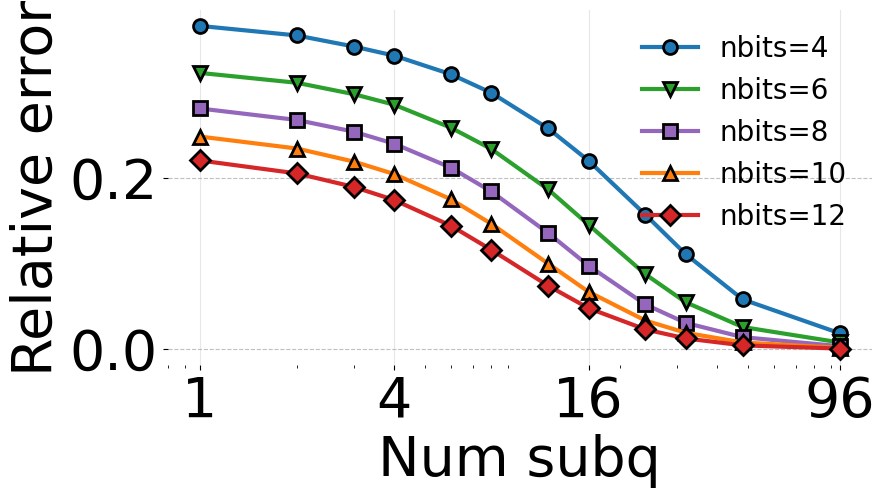


Plotting: ADC time (seconds) vs Num subq (grouped by nbits)
Methods: ['PQ'], Datasets: ['deep']

Saved figure to /data/cpanourg/2-hdvc/results/relerr_cpp/figures/adctimes_pq_deep_nsubquantizers.pdf


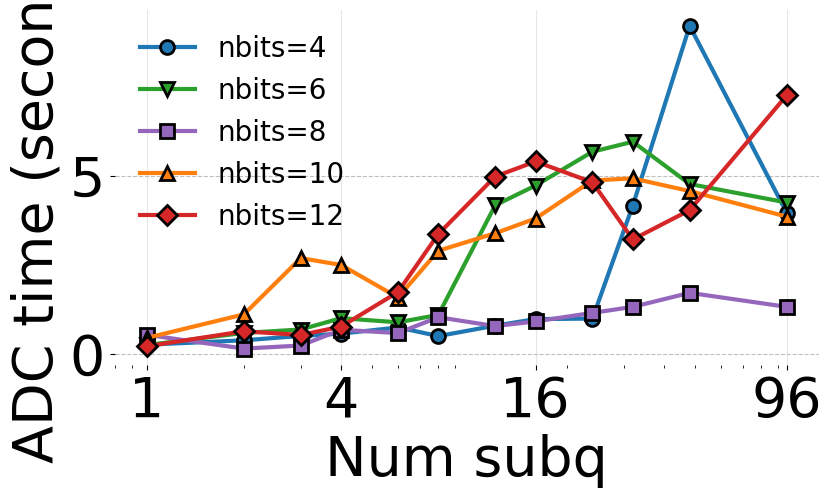

In [31]:
# Color and marker configuration for grouping variables
NBITS_COLORS = {
    4: "tab:blue",
    6: "tab:green",
    8: "tab:purple",
    10: "tab:orange",
    12: "tab:red",
}

NBITS_MARKERS = {
    4: "o",
    6: "v",
    8: "s",
    10: "^",
    12: "D",
}

SUBQ_COLORS = {
    1: "tab:blue",
    2: "tab:green",
    3: "tab:orange",
    4: "tab:red",
    6: "tab:purple",
    8: "tab:brown",
    12: "tab:pink",
    16: "tab:gray",
    24: "tab:olive",
    32: "tab:cyan",
    48: "tab:blue",
    96: "tab:orange",
}

SUBQ_MARKERS = {
    1: "o",
    2: "s",
    3: "^",
    4: "D",
    6: "v",
    8: "<",
    12: ">",
    16: "p",
    24: "*",
    32: "h",
    48: "H",
    96: "X",
}


def plot_relerr_vs_x(
    df: pd.DataFrame, 
    x_col: str, 
    x_label: str, 
    y_col: str = "rel_error_mean",
    y_label: str = None,
    methods: list = None,
    datasets: list = None,
    ylim: tuple = None,
    group_by: str = None,
    output_dir: Path = None
):
    """
    Plot `y_col` vs `x_col`, with separate figures per method and dataset.
    
    Grouping logic:
    - When x_col is 'n_subquantizers': separate curves by nbits.
    - When x_col is 'nbits': separate curves by n_subquantizers.
    - When x_col is 'bits_per_vector': grouping is controlled by BITS_PER_VECTOR_GROUPING config
      (can be "nbits" or "n_subquantizers").
    
    Args:
        df: DataFrame with results
        x_col: Column name to plot on x-axis
        x_label: Display label for x-axis
        y_col: Column name to plot on y-axis (default: "rel_error_mean")
        y_label: Display label for y-axis (if None, auto-generated from y_col)
        methods: List of methods to plot (if None, uses all available)
        datasets: List of datasets to plot (if None, uses all available)
        ylim: Optional tuple (ymin, ymax) to set y-axis limits (if None, uses auto)
        group_by: Optional override for grouping ("nbits" or "n_subquantizers"). If None, uses default logic.
        output_dir: Directory to save plots
    """
    if methods is None:
        methods = sorted(df["method"].unique())
    if datasets is None:
        datasets = sorted(df["dataset"].unique())
    
    if output_dir is None:
        output_dir = Path("./../../experiments/plots/relerr_cpp")
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Determine grouping variable based on x_col (or use group_by if provided)
    if group_by is not None:
        # Override default grouping with explicit group_by parameter
        if group_by == "nbits":
            group_col = "nbits"
            color_map = NBITS_COLORS
            marker_map = NBITS_MARKERS
            group_label_prefix = "nbits="
        elif group_by == "n_subquantizers":
            group_col = "n_subquantizers"
            color_map = SUBQ_COLORS
            marker_map = SUBQ_MARKERS
            group_label_prefix = "subq="
        else:
            raise ValueError(f"group_by must be 'nbits' or 'n_subquantizers', got {group_by}")
    elif x_col == "n_subquantizers":
        group_col = "nbits"
        color_map = NBITS_COLORS
        marker_map = NBITS_MARKERS
        group_label_prefix = "nbits="
    elif x_col == "nbits":
        group_col = "n_subquantizers"
        color_map = SUBQ_COLORS
        marker_map = SUBQ_MARKERS
        group_label_prefix = "subq="
    elif x_col == "bits_per_vector":
        # Use configuration to determine grouping
        if BITS_PER_VECTOR_GROUPING == "nbits":
            group_col = "nbits"
            color_map = NBITS_COLORS
            marker_map = NBITS_MARKERS
            group_label_prefix = "nbits="
        else:  # default to n_subquantizers
            group_col = "n_subquantizers"
            color_map = SUBQ_COLORS
            marker_map = SUBQ_MARKERS
            group_label_prefix = "subq="
    else:
        # For other columns, default to grouping by nbits
        group_col = "nbits"
        color_map = NBITS_COLORS
        marker_map = NBITS_MARKERS
        group_label_prefix = "nbits="
    
    for method in methods:
        for dataset in datasets:
            sub = df[(df["method"] == method) & (df["dataset"] == dataset)].copy()
            if sub.empty:
                continue
            
            # Set large font size like reference notebook
            plt.rcParams.update({"font.size": 40})
            fig, ax = plt.subplots(figsize=(10, 6))
            
            # Get unique values for grouping variable
            group_vals = sorted(sub[group_col].unique())
            
            for gval in group_vals:
                sub_group = sub[sub[group_col] == gval].copy()
                if sub_group.empty:
                    continue
                sub_group = sub_group.sort_values(by=x_col)
                
                ax.plot(
                    sub_group[x_col],
                    sub_group[y_col],
                    label=f"{group_label_prefix}{int(gval)}",
                    color=color_map.get(int(gval), "black"),
                    marker=marker_map.get(int(gval), "o"),
                    linestyle="-",
                    linewidth=3.0,  # Thick lines
                    markersize=10,
                    markeredgewidth=2,
                    markeredgecolor="black",
                )
            
            ax.set_xlabel(x_label, fontsize=40)
            # Set y-axis label - use provided y_label or generate from y_col
            if y_label is None:
                if y_col == "rel_error_mean":
                    y_label = "Relative error"
                elif y_col == "adc_time_s":
                    y_label = "ADC time (seconds)"
                else:
                    y_label = y_col.replace("_", " ").title()
            ax.set_ylabel(y_label, fontsize=40)
            # No title - method and dataset are specified as inputs
            ax.tick_params(labelsize=40)
            
            # Set y-axis limits if specified
            if ylim is not None:
                ax.set_ylim(ylim)
            # Use log scale for subquantizers (like reference image)
            # You can add other columns here if you want log scale
            if x_col == "n_subquantizers":
                ax.set_xscale("log")
                # Get unique subquantizer values from data and select 3-4 evenly spaced ticks
                unique_subq = sorted(sub[x_col].unique())
                if len(unique_subq) > 4:
                    # Select 4 evenly spaced indices
                    indices = np.linspace(0, len(unique_subq) - 1, 4, dtype=int)
                    tick_values = [unique_subq[i] for i in indices]
                else:
                    tick_values = unique_subq
                # Store tick values to reapply after tight_layout
                tick_values_to_use = tick_values
            else:
                # Limit to 3-4 ticks for linear axes
                # Check if values are integers
                unique_vals = sorted(sub[x_col].unique())
                if all(isinstance(v, (int, np.integer)) or (isinstance(v, float) and v.is_integer()) for v in unique_vals):
                    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))
                else:
                    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
                tick_values_to_use = None
            
            # Grid styling like reference
            ax.grid(alpha=0.8, axis='y', linestyle='--')
            for spine in ax.spines.values():
                spine.set_visible(False)
            
            # Place legend outside plot when nbits or bits_per_vector is x-axis to avoid interference
            if x_col in ["nbits", "bits_per_vector"]:
                ax.legend(frameon=False, fontsize=20, loc='center left', bbox_to_anchor=(1.05, 0.5))
            else:
                ax.legend(frameon=False, fontsize=20, loc='best')
            
            # Apply tight_layout first
            plt.tight_layout()
            
            # Re-apply ticks for log scale after tight_layout to ensure they're preserved
            if x_col == "n_subquantizers" and tick_values_to_use is not None:
                ax.set_xticks(tick_values_to_use)
                ax.set_xticklabels([int(x) for x in tick_values_to_use])
            
            # Save figure with consistent DPI
            safe_method = method.lower()
            safe_dataset = dataset.lower()
            safe_x = x_col.replace("_", "")
            # Include y_col in filename if it's not the default
            if y_col != "rel_error_mean":
                safe_y = y_col.replace("_", "")
                savepath = output_dir / f"{safe_y}_{safe_method}_{safe_dataset}_{safe_x}.pdf"
            else:
                savepath = output_dir / f"relerr_{safe_method}_{safe_dataset}_{safe_x}.pdf"
            fig.savefig(savepath, bbox_inches='tight', dpi=300)
            print(f"Saved figure to {savepath}")
            
            plt.show()
            plt.close(fig)


# Generate plots based on configuration
for x_col, x_label in X_COLUMNS_TO_PLOT:
    # Check if column exists in dataframe
    if x_col not in relerr_df.columns:
        print(f"Warning: Column '{x_col}' not found in dataframe. Skipping...")
        continue
    
    # Get ylim for this x-axis column if specified
    ylim = YLIM_CONFIG.get(x_col, None)
    
    print(f"\n{'='*60}")
    print(f"Plotting: Relative error vs {x_label}")
    print(f"Methods: {METHODS_TO_PLOT}, Datasets: {DATASETS_TO_PLOT}")
    if ylim is not None:
        print(f"Y-axis limits: {ylim}")
    print(f"{'='*60}\n")
    plot_relerr_vs_x(
        relerr_df, 
        x_col, 
        x_label,
        methods=METHODS_TO_PLOT,
        datasets=DATASETS_TO_PLOT,
        ylim=ylim,
        output_dir=Path("/data/cpanourg/2-hdvc/results/relerr_cpp/figures")
    )

# Generate additional plots with different y-axis columns
for x_col, x_label, y_col, y_label, group_by in ADDITIONAL_PLOTS:
    # Check if columns exist in dataframe
    if x_col not in relerr_df.columns:
        print(f"Warning: Column '{x_col}' not found in dataframe. Skipping...")
        continue
    if y_col not in relerr_df.columns:
        print(f"Warning: Column '{y_col}' not found in dataframe. Skipping...")
        continue
    
    # Get ylim for this x-axis column if specified
    ylim = YLIM_CONFIG.get(x_col, None)
    
    print(f"\n{'='*60}")
    print(f"Plotting: {y_label} vs {x_label} (grouped by {group_by})")
    print(f"Methods: {METHODS_TO_PLOT}, Datasets: {DATASETS_TO_PLOT}")
    if ylim is not None:
        print(f"Y-axis limits: {ylim}")
    print(f"{'='*60}\n")
    plot_relerr_vs_x(
        relerr_df, 
        x_col, 
        x_label,
        y_col=y_col,
        y_label=y_label,
        methods=METHODS_TO_PLOT,
        datasets=DATASETS_TO_PLOT,
        ylim=ylim,
        group_by=group_by,
        output_dir=Path("/data/cpanourg/2-hdvc/results/relerr_cpp/figures")
    )